In [4]:
!pip install plotly


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np

# ----------------------------
# 1) Load dataset
# ----------------------------
path = "social_media_viral_content_dataset.csv"
df = pd.read_csv(path)

df["post_datetime"] = pd.to_datetime(df["post_datetime"], errors="coerce")
df["is_viral"] = df["is_viral"].astype(int)

# Quick summary
print("Shape:", df.shape)
print(df["is_viral"].value_counts())
print(df.groupby("is_viral")[["views","engagement_rate"]].mean())

Shape: (2000, 15)
is_viral
1    1398
0     602
Name: count, dtype: int64
                 views  engagement_rate
is_viral                               
0         1.013173e+06         0.339711
1         5.693697e+06         0.079540


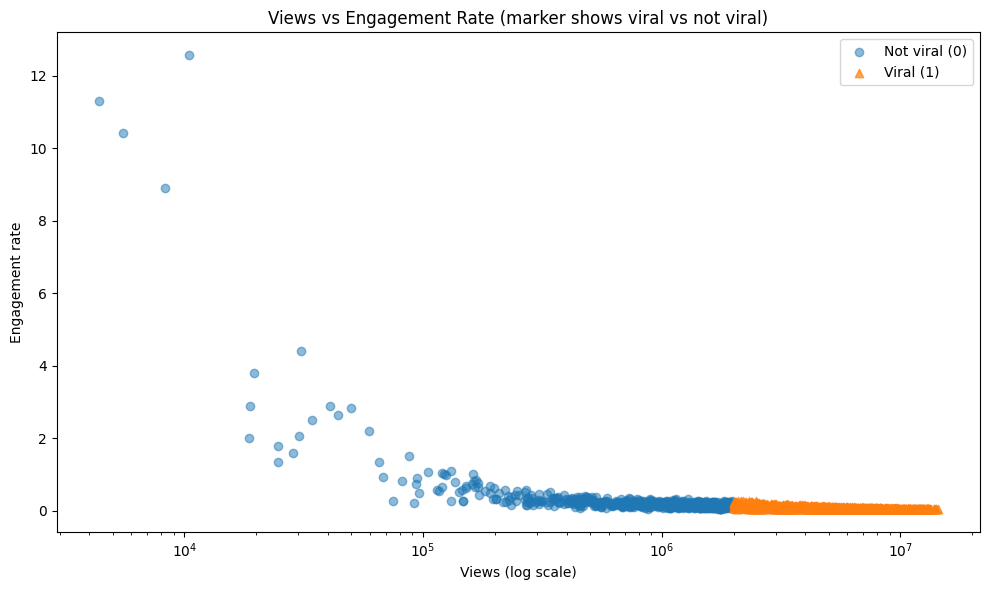

In [2]:

# ----------------------------
# 2) Matplotlib visualization (saved as PNG)
# ----------------------------
import matplotlib.pyplot as plt

viral = df[df["is_viral"] == 1]
nonviral = df[df["is_viral"] == 0]

plt.figure(figsize=(10, 6))
plt.scatter(nonviral["views"], nonviral["engagement_rate"], alpha=0.5, label="Not viral (0)", marker="o")
plt.scatter(viral["views"], viral["engagement_rate"], alpha=0.7, label="Viral (1)", marker="^")
plt.xscale("log")
plt.xlabel("Views (log scale)")
plt.ylabel("Engagement rate")
plt.title("Views vs Engagement Rate (marker shows viral vs not viral)")
plt.legend()
plt.tight_layout()
plt.savefig("views_vs_engagement_viral.png", dpi=200)
plt.show()

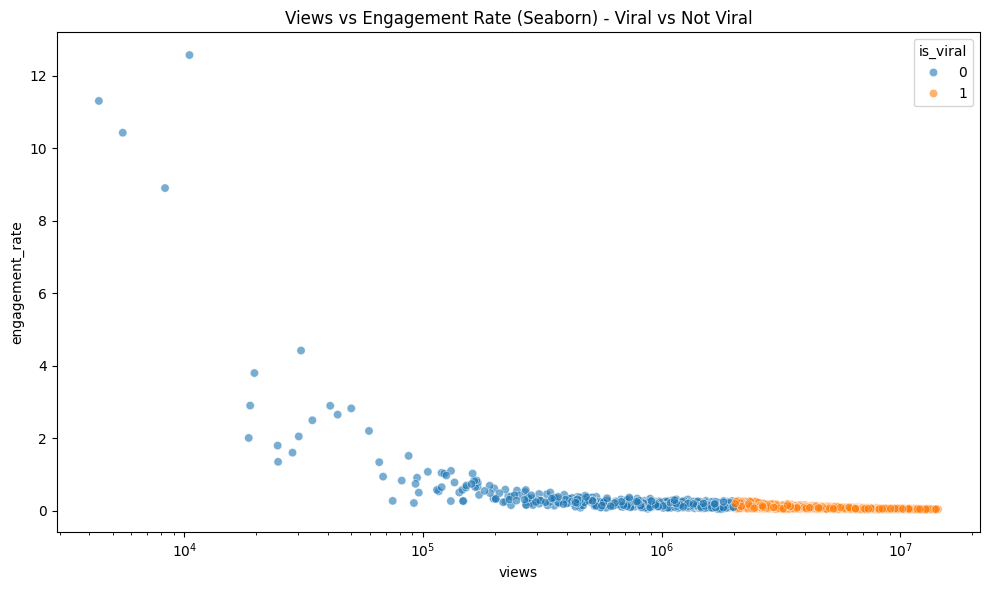

In [3]:


# ----------------------------
# 3) Seaborn version (optional)
# ----------------------------
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="views",
    y="engagement_rate",
    hue="is_viral",
    alpha=0.6
)
plt.xscale("log")
plt.title("Views vs Engagement Rate (Seaborn) - Viral vs Not Viral")
plt.tight_layout()
plt.show()


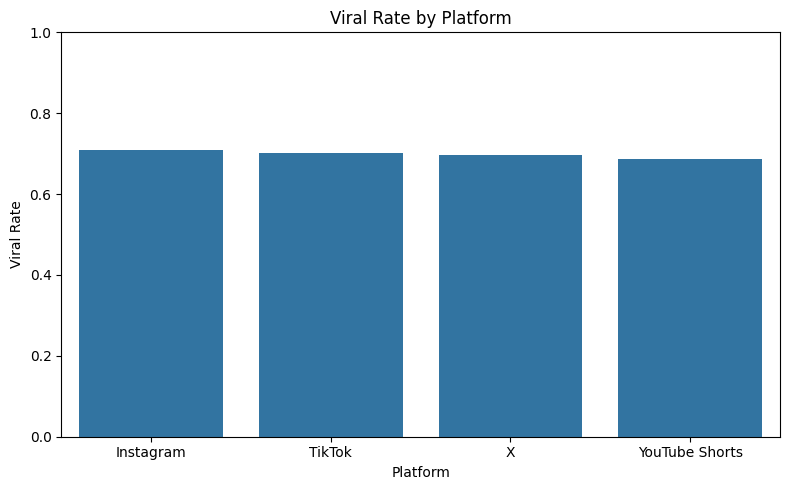

In [4]:
# Convert target to numeric
df["is_viral"] = df["is_viral"].astype(int)

# Compute viral rate by platform
viral_rate = (
    df.groupby("platform")["is_viral"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=viral_rate, x="platform", y="is_viral")
plt.ylabel("Viral Rate")
plt.xlabel("Platform")
plt.title("Viral Rate by Platform")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("viral_rate_by_platform.png", dpi=200)
plt.show()